# 04 - Multiple Linear Regression
Classical statistical modelling of TEC using solar and geomagnetic indices.

In [1]:
from pathlib import Path
import numpy as np,pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
%matplotlib inline

In [2]:
ROOT=Path.cwd().parent
df=pd.read_csv(ROOT/'data'/'processed'/'master_dataset.csv')
df['date']=pd.to_datetime(df['date'])
features=['ssn','kp_mean','ap_daily','f107_obs','dst_daily_mean']
target='daily_mean_tec'
data=df[features+[target]].dropna()
X=data[features]; y=data[target]

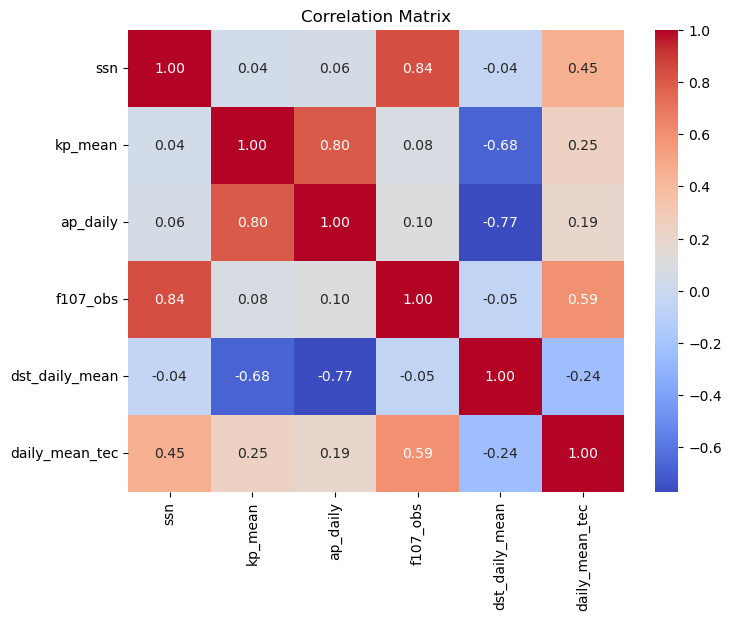

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [7]:
X_const=sm.add_constant(X)
vif=pd.DataFrame({'Variable':X_const.columns,'VIF':[variance_inflation_factor(X_const.values,i) for i in range(X_const.shape[1])]})
print(vif)
model=sm.OLS(y,X_const).fit()
print(model.summary())

         Variable        VIF
0           const  24.022552
1             ssn   3.372106
2         kp_mean   2.813290
3        ap_daily   3.775510
4        f107_obs   3.402399
5  dst_daily_mean   2.541276
                            OLS Regression Results                            
Dep. Variable:         daily_mean_tec   R-squared:                       0.423
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     159.6
Date:                Sat, 18 Jul 2026   Prob (F-statistic):          2.84e-127
Time:                        23:05:16   Log-Likelihood:                -3739.6
No. Observations:                1095   AIC:                             7491.
Df Residuals:                    1089   BIC:                             7521.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
       

In [9]:
pred=model.predict(X_const)
mae=mean_absolute_error(y,pred)
rmse=np.sqrt(mean_squared_error(y,pred))
r2=r2_score(y,pred)
print({'MAE':mae,'RMSE':rmse,'R2':r2})

{'MAE': 5.982429840923169, 'RMSE': 7.361241606238204, 'R2': 0.42282787774458297}


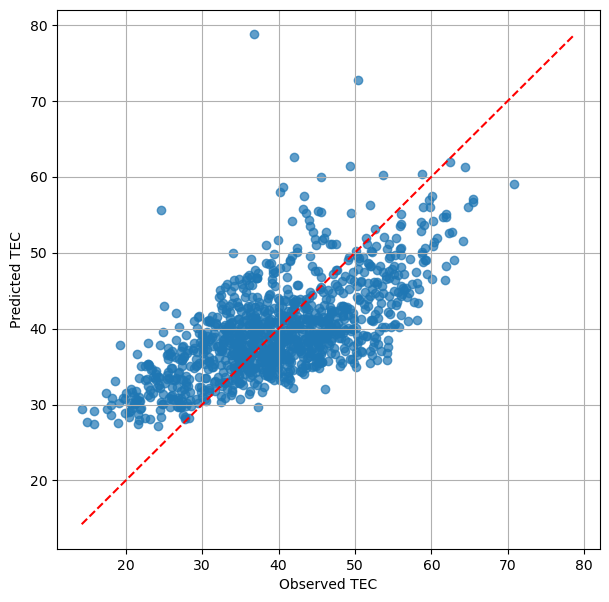

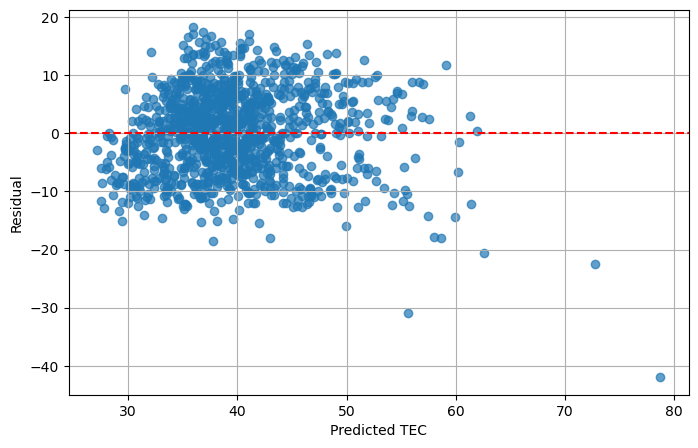

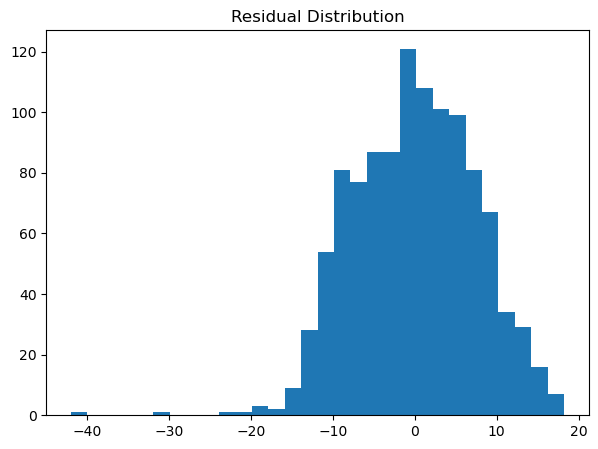

In [11]:
plt.figure(figsize=(7,7))
plt.scatter(y,pred,alpha=0.7)
mn=min(y.min(),pred.min()); mx=max(y.max(),pred.max())
plt.plot([mn,mx],[mn,mx],'r--')
plt.xlabel('Observed TEC'); plt.ylabel('Predicted TEC'); plt.grid(); plt.show()

res=y-pred
plt.figure(figsize=(8,5))
plt.scatter(pred,res,alpha=0.7)
plt.axhline(0,color='red',linestyle='--')
plt.xlabel('Predicted TEC'); plt.ylabel('Residual'); plt.grid(); plt.show()

plt.figure(figsize=(7,5))
plt.hist(res,bins=30)
plt.title('Residual Distribution')
plt.show()

In [13]:
results=ROOT/'results'
results.mkdir(exist_ok=True)
pd.DataFrame({'Observed':y,'Predicted':pred,'Residual':res}).to_csv(results/'mlr_predictions.csv',index=False)